<a href="https://colab.research.google.com/github/tunasw1975/Python/blob/main/direct_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

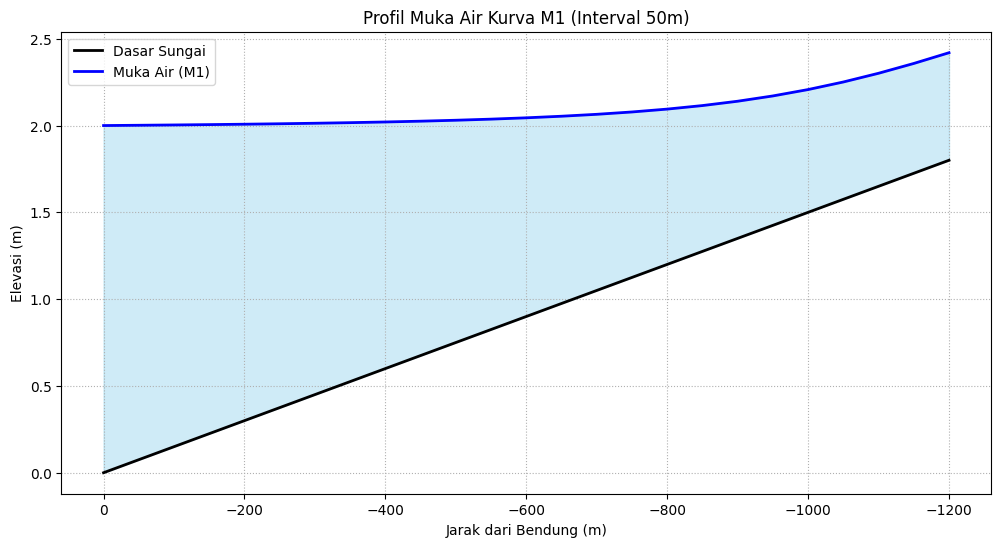

Jarak (m)  | Elev Dasar   | Kedalaman  | Elev Air  
--------------------------------------------------
0          | -0.000       | 2.000      | 2.000     
-50        | 0.075        | 1.927      | 2.002     
-100       | 0.150        | 1.853      | 2.003     
-150       | 0.225        | 1.780      | 2.005     
-200       | 0.300        | 1.708      | 2.008     
-250       | 0.375        | 1.635      | 2.010     
-300       | 0.450        | 1.563      | 2.013     
-350       | 0.525        | 1.492      | 2.017     
-400       | 0.600        | 1.421      | 2.021     
-450       | 0.675        | 1.350      | 2.025     
-500       | 0.750        | 1.281      | 2.031     
-550       | 0.825        | 1.212      | 2.037     
-600       | 0.900        | 1.145      | 2.045     
-650       | 0.975        | 1.079      | 2.054     
-700       | 1.050        | 1.015      | 2.065     
-750       | 1.125        | 0.953      | 2.078     
-800       | 1.200        | 0.895      | 2.095     
-850       | 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
Q, B, n, S0, g = 5.0, 10.0, 0.03, 0.0015, 9.81
y_start = 2.0
yn = 0.612

# Fungsi Energi Spesifik
def energy(y):
    v = Q / (B * y)
    return y + (v**2 / (2 * g))

# Fungsi Slope Energi (Manning)
def friction_slope(y):
    A = B * y
    P = B + 2 * y
    R = A / P
    return (n * Q / (A * R**(2/3)))**2

# Perhitungan Direct Step
y_vals = np.linspace(y_start, yn + 0.001, 100)
x_coords = [0]
y_coords = [y_start]

for i in range(len(y_vals)-1):
    y1, y2 = y_vals[i], y_vals[i+1]
    E1, E2 = energy(y1), energy(y2)
    Sf1, Sf2 = friction_slope(y1), friction_slope(y2)
    avg_Sf = (Sf1 + Sf2) / 2

    dx = (E2 - E1) / (S0 - avg_Sf)
    x_coords.append(x_coords[-1] + dx)
    y_coords.append(y2)

# Interpolasi untuk mendapatkan data tiap 50m
x_new = np.arange(0, min(x_coords), -50)
y_new = np.interp(x_new, x_coords[::-1], y_coords[::-1])
z_new = -x_new * S0 # Elevasi dasar naik ke hulu

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(x_new, z_new, 'k-', label='Dasar Sungai', linewidth=2)
plt.plot(x_new, z_new + y_new, 'b-', label='Muka Air (M1)', linewidth=2)
plt.fill_between(x_new, z_new, z_new + y_new, color='skyblue', alpha=0.4)

plt.title('Profil Muka Air Kurva M1 (Interval 50m)')
plt.xlabel('Jarak dari Bendung (m)')
plt.ylabel('Elevasi (m)')
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

# Print Tabel 50m
print(f"{'Jarak (m)':<10} | {'Elev Dasar':<12} | {'Kedalaman':<10} | {'Elev Air':<10}")
print("-" * 50)
for i in range(len(x_new)):
    print(f"{x_new[i]:<10.0f} | {z_new[i]:<12.3f} | {y_new[i]:<10.3f} | {z_new[i]+y_new[i]:<10.3f}")